## Importing all the libraries

In [20]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_squared_error, 
    r2_score, 
    accuracy_score, 
    precision_recall_fscore_support, 
    confusion_matrix, 
    ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

## Loading datasets

In [8]:
df = pd.read_csv('dataset/Earthquake.csv')

print(df.head())

                       time  latitude  longitude    depth  mag magType    nst  \
0  2026-05-30T21:15:59.807Z   38.3564    73.8219  131.794  4.9      mb   80.0   
1  2026-05-29T12:22:54.128Z   23.4621    93.7220   57.374  4.3      mb   32.0   
2  2026-05-28T02:37:50.460Z   33.1393    96.1517   10.000  4.7      mb  111.0   
3  2026-05-26T16:30:57.714Z   23.1849    94.5425  102.712  4.3      mb   21.0   
4  2026-05-26T14:07:51.354Z   23.7982    94.8304  112.776  4.5      mb   36.0   

     gap   dmin   rms  ...                   updated  \
0   78.0  1.052  0.94  ...  2026-05-30T21:35:21.040Z   
1  126.0  2.503  0.68  ...  2026-05-29T12:58:49.040Z   
2   47.0  5.492  0.73  ...  2026-05-28T05:26:32.040Z   
3  158.0  2.000  0.43  ...  2026-05-27T14:59:41.040Z   
4   68.0  2.581  0.40  ...  2026-05-26T17:07:05.040Z   

                                   place        type horizontalError  \
0       24 km NNW of Murghob, Tajikistan  earthquake            7.07   
1      60 km N of Falam, Burma (

## Data preprocessing

In [9]:
columns_needed = ["latitude", "longitude", "depth", "mag"]
df_cleaned = df[columns_needed].copy()
df_cleaned = df_cleaned.dropna().drop_duplicates()

## Feature Engineering

In [10]:
X = df_cleaned[['latitude', 'longitude', 'depth']]
y = df_cleaned['mag'] # target variables

## Train and Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nTraining set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (13680, 3)
Testing set shape: (3420, 3)


## Random Forest
For random forest we tune n_estimators and max_depth. So,

In [12]:
best_n_estimators = 100
best_max_depth = 15

## Training Model

In [13]:
rf_model = RandomForestRegressor(n_estimators=best_n_estimators, max_depth=best_max_depth, random_state=42)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

## Evaluation

In [14]:
y_pred = rf_model.predict(X_test)

# 3. Regression Metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"R2 Score: {r2:.4f}\n")

RMSE: 0.4003
R2 Score: 0.0464



Bins

In [15]:
def bin_magnitude(val):
    if val < 3.0:
        return 'Minor'
    elif val < 5.0:
        return 'Light/Moderate'
    else:
        return 'Strong'

y_test_binned = y_test.apply(bin_magnitude)
y_pred_binned = pd.Series(y_pred, index=y_test.index).apply(bin_magnitude)

# Classification Metrics

In [16]:
accuracy = accuracy_score(y_test_binned, y_pred_binned)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test_binned, y_pred_binned, average='weighted', zero_division=0
)

print("=== Random Forest Classification Metrics ===")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}\n")

=== Random Forest Classification Metrics ===
Accuracy:  0.8535
Precision: 0.7996
Recall:    0.8535
F1-Score:  0.8037



# Confusion Matrix

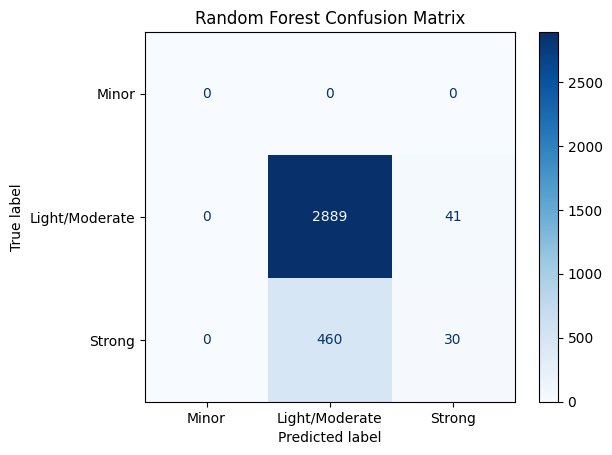

In [17]:
labels = ['Minor', 'Light/Moderate', 'Strong']

cm = confusion_matrix(y_test_binned, y_pred_binned, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.show()

## Analyze prediction

In [18]:
def predict_new_coordinate(latitude, longitude, depth):
    input_data = pd.DataFrame([[latitude, longitude, depth]], columns=['latitude', 'longitude', 'depth'])
    predicted_mag = rf_model.predict(input_data)[0]
    risk_class = bin_magnitude(predicted_mag)
    return {
        "Predicted Magnitude": round(predicted_mag, 2),
        "Risk Category": risk_class
    }

In [19]:
print(predict_new_coordinate(34.0522, -118.2437, 12.5))

{'Predicted Magnitude': np.float64(4.91), 'Risk Category': 'Light/Moderate'}
